# Applied Statistics and Inference|Assignment

Q1 : What are Type I and Type II errors in hypothesis testing, and how do they
impact decision-making?

Ans:-
Type I Error: This occurs when we reject the null hypothesis even though it is actually true. It means we conclude there is an effect when there is none.
Impact: Leads to false alarms and incorrect decisions based on something that is not real.

Type II Error: This occurs when we fail to reject the null hypothesis even though it is false. It means we miss a real effect.
Impact: Leads to missed opportunities or failing to detect something important.



Q2 : What is the P-value in hypothesis testing, and how should it be interpreted
in the context of the null hypothesis?

Ans:- 
P-value:   The p-value tells us how likely our results are if the null hypothesis is actually true. It basically measures how surprising the data is. If the p-value is very small, it means the result is unlikely to happen by chance, so we question the null hypothesis and usually reject it. If the p-value is large, the result can easily happen by chance, so we keep the null hypothesis.

Q3: Explain the difference between a Z-test and a T-test, including when to use each.

Ans:
 A Z-test is used when the sample size is large (usually more than 30) and the population standard deviation is known. It works best when the data is normally distributed and we have a lot of information.

A T-test is used when the sample size is small (less than 30) or when the population standard deviation is unknown. It is more flexible and works well with small datasets.

Q-5 :Describe the purpose and assumptions of an ANOVA test. How does it
extend hypothesis testing to more than two groups?

Ans:-

Purpose of ANOVA-
ANOVA (Analysis of Variance) is used to check whether three or more groups have significantly different means. Instead of comparing groups two at a time, ANOVA tests all groups together in one test.

Assumptions of ANOVA:
Normality: The data in each group should be roughly normally distributed.
Equal Variances: All groups should have similar variance (spread).
Independence: The observations in each group must be independent of each other.

How it extends hypothesis testing:
A t-test compares only two groups. ANOVA extends this idea to more than two groups by testing if at least one group mean is different. If ANOVA shows a difference, further tests (post hoc tests) can find which groups differ.

In [5]:
# Q6 : Write a Python program to perform a one-sample Z-test and interpret theresult for a given dataset.

import numpy as np
import math

# Sample dataset
data = [52, 48, 50, 55, 47, 49, 51, 53, 50, 52]

# Known population mean and standard deviation
population_mean = 50
population_std = 4  # known population SD

# Calculate sample statistics
sample_mean = np.mean(data)
sample_size = len(data)

# Z-test calculation
z_value = (sample_mean - population_mean) / (population_std / math.sqrt(sample_size))

# Function to calculate p-value (two-tailed) without SciPy
def normal_cdf(x):
    return (1 + math.erf(x / math.sqrt(2))) / 2

p_value = 2 * (1 - normal_cdf(abs(z_value)))

print("Sample Mean:", sample_mean)
print("Z-value:", z_value)
print("P-value:", p_value)

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("Result: Reject the null hypothesis.")
    print("Interpretation: The sample mean is significantly different from the population mean.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("Interpretation: There is no significant difference between the sample and population mean.")



Sample Mean: 50.7
Z-value: 0.5533985905294686
P-value: 0.5799905038550068
Result: Fail to reject the null hypothesis.
Interpretation: There is no significant difference between the sample and population mean.


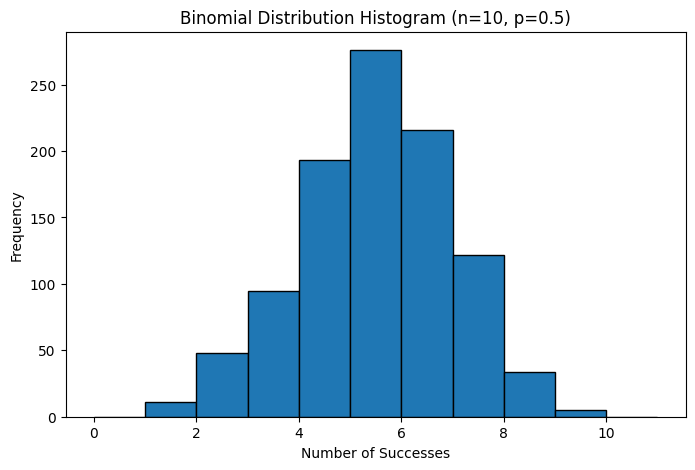

In [18]:

# Q7: Simulate a dataset from a binomial distribution (n = 10, p = 0.5) using NumPy and plot the histogram.

#!pip install matplotlib

import numpy as np
import matplotlib.pyplot as plt

# Simulate binomial dataset
n = 10        # number of trials
p = 0.5       # probability of success
size = 1000   # number of samples

data = np.random.binomial(n, p, size)

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(data, bins=range(0, n+2), edgecolor='black')
plt.xlabel('Number of Successes')
plt.ylabel('Frequency')
plt.title('Binomial Distribution Histogram (n=10, p=0.5)')
plt.show()

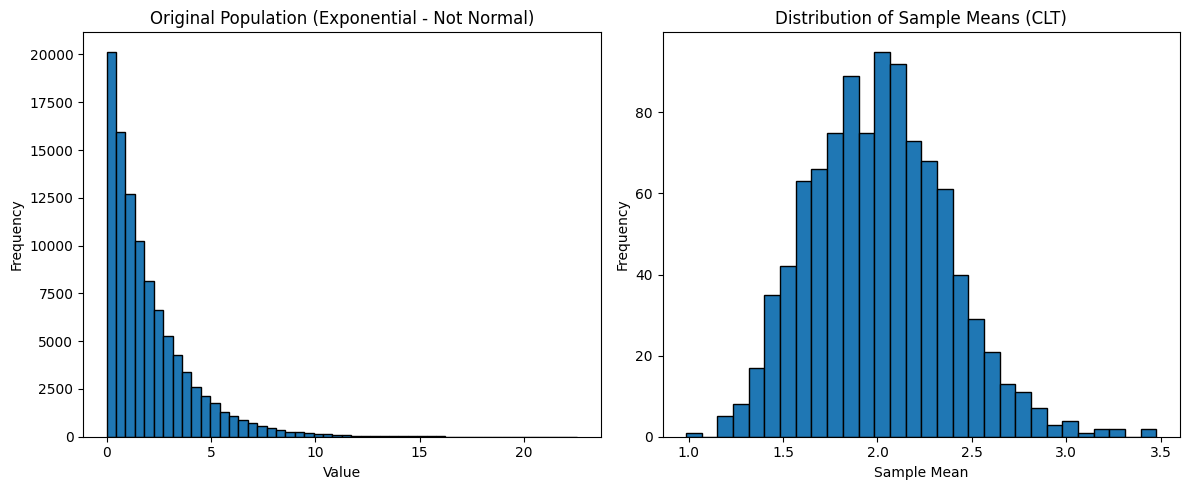

In [19]:
# Q8: Generate multiple samples from a non-normal distribution and implement the Central Limit Theorem using Python.

import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate data from a NON-NORMAL distribution (Exponential)
population = np.random.exponential(scale=2, size=100000)

# Step 2: Central Limit Theorem Simulation
sample_size = 30          # sample size for each sample
num_samples = 1000        # how many samples to take

sample_means = []

for _ in range(num_samples):
    sample = np.random.choice(population, size=sample_size, replace=True)
    sample_means.append(np.mean(sample))

# Step 3: Plot population distribution (skewed)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(population, bins=50, edgecolor='black')
plt.title("Original Population (Exponential - Not Normal)")
plt.xlabel("Value")
plt.ylabel("Frequency")

# Step 4: Plot distribution of sample means (Should look normal)
plt.subplot(1,2,2)
plt.hist(sample_means, bins=30, edgecolor='black')
plt.title("Distribution of Sample Means (CLT)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()



Sample Mean: 14.6
95% Confidence Interval: (13.666853352003734, 15.533146647996265)


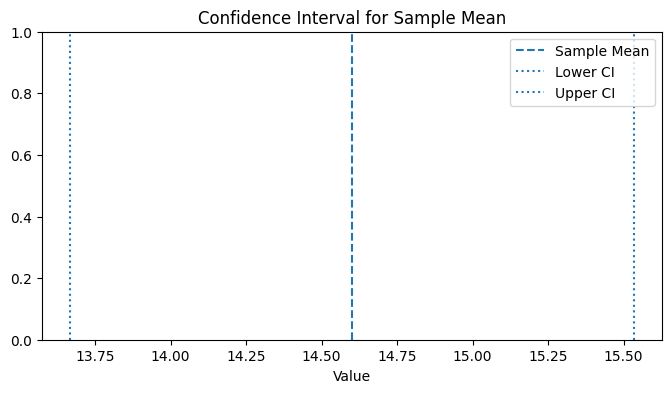

(np.float64(13.666853352003734), np.float64(15.533146647996265))

In [21]:
# Q9: Write a Python function to calculate and visualize the confidence interval for a sample mean.

import numpy as np
import matplotlib.pyplot as plt
import math

def confidence_interval_plot(data, confidence=0.95):
    # Calculate sample statistics
    sample_mean = np.mean(data)
    sample_std = np.std(data, ddof=1)
    n = len(data)

    # Z-value for 95% CI (you can change confidence)
    z = 1.96  

    # Margin of error
    margin_error = z * (sample_std / math.sqrt(n))

    # Confidence interval
    lower = sample_mean - margin_error
    upper = sample_mean + margin_error

    print(f"Sample Mean: {sample_mean}")
    print(f"95% Confidence Interval: ({lower}, {upper})")

    # Visualization
    plt.figure(figsize=(8,4))
    plt.axvline(sample_mean, linestyle='--', label='Sample Mean')
    plt.axvline(lower, linestyle=':', label='Lower CI')
    plt.axvline(upper, linestyle=':', label='Upper CI')
    plt.title("Confidence Interval for Sample Mean")
    plt.xlabel("Value")
    plt.legend()
    plt.show()

    return lower, upper

# Example usage
data = [12, 15, 14, 16, 13, 17, 14, 15, 16, 14]
confidence_interval_plot(data)


In [26]:
# Q10: Perform a Chi-square goodness-of-fit test using Python to compare observed and expected distributions, and explain the outcome.

import numpy as np

# Observed and expected frequencies
observed = np.array([50, 30, 20])
expected = np.array([40, 40, 20])

# Chi-square statistic formula
chi2_stat = np.sum((observed - expected)**2 / expected)

print("Chi-square Statistic:", chi2_stat)

# To check significance, compare with chi-square critical value
# For 3 categories → df = 3 - 1 = 2
critical_value = 5.99   # Chi-square critical value for df=2 at α=0.05

if chi2_stat > critical_value:
    print("Result: Reject the null hypothesis.")
    print("Interpretation: Observed distribution is different from expected.")
else:
    print("Result: Fail to reject the null hypothesis.")
    print("Interpretation: Observed distribution fits expected distribution.")


Chi-square Statistic: 5.0
Result: Fail to reject the null hypothesis.
Interpretation: Observed distribution fits expected distribution.
